# MBA Admissions - Decision Tree, Random Forest and Gradient Boosting

| Name | Student ID |
|---|---|
| Kiatisak Markmeeshap | 67070501005 |

Same method as `mba-admissions-data-classification-knnmethod.ipynb` by Seyedvala Khorasani
- same three-class target, same one-hot encoding, same scaling, same 80/20 split with
`random_state=4` - with the three tree models in place of KNN.

One deliberate change, and section 3 shows why it is necessary.

## Import necessary packages

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import metrics, preprocessing
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

## Read in data

In [2]:
df = pd.read_csv("MBA.csv")
print(df.head())
print(df.describe())

   application_id  gender  international   gpa       major      race   gmat  \
0               1  Female          False  3.30    Business     Asian  620.0   
1               2    Male          False  3.28  Humanities     Black  680.0   
2               3  Female           True  3.30    Business       NaN  710.0   
3               4    Male          False  3.47        STEM     Black  690.0   
4               5    Male          False  3.35        STEM  Hispanic  590.0   

   work_exp          work_industry admission  
0       3.0     Financial Services     Admit  
1       5.0  Investment Management       NaN  
2       5.0             Technology     Admit  
3       6.0             Technology       NaN  
4       5.0             Consulting       NaN  
       application_id          gpa         gmat     work_exp
count     6194.000000  6194.000000  6194.000000  6194.000000
mean      3097.500000     3.250714   651.092993     5.016952
std       1788.198115     0.151541    49.294883     1.032432

## Converting categorical data to numerical format

`admission` is text with blanks. Following the reference: `Admit` becomes 1, `Waitlist`
becomes 2, and the blanks become 0 - the applicants who were turned down.

In [3]:
df["admission"] = df["admission"].map({"Admit": 1, "Waitlist": 2}).fillna(0)
df["admission"].value_counts()

admission
0.0    5194
1.0     900
2.0     100
Name: count, dtype: int64

In [4]:
categorical_columns = ["gender", "major", "race", "work_industry"]
df_encoded = pd.get_dummies(df, columns=categorical_columns)
df_encoded.shape

(6194, 30)

## 3. The feature list, and one change to it

The reference builds its feature matrix like this:

```python
X = df_encoded[['gpa', 'gmat', 'work_exp', 'admission',
                'gender_Female', 'gender_Male', ...]].values
y = df[['admission']].values
```

`admission` appears in both. The model is handed the answer as an input column, which is
why that notebook reports 98.87% test accuracy. Trees make the problem impossible to
miss - watch what they score with the column left in.

In [5]:
FEATURES = [
    "gpa", "gmat", "work_exp",
    "gender_Female", "gender_Male", "major_Business", "major_Humanities",
    "work_industry_Health Care", "work_industry_Investment Banking",
    "work_industry_Investment Management", "work_industry_Media/Entertainment",
    "work_industry_Nonprofit/Gov", "work_industry_Other", "work_industry_PE/VC",
    "work_industry_Real Estate", "work_industry_Retail", "work_industry_Technology",
]

y = df["admission"].values

leaky = preprocessing.StandardScaler().fit_transform(
    df_encoded[["admission"] + FEATURES].values.astype(float))
Xl_train, Xl_test, yl_train, yl_test = train_test_split(leaky, y, test_size=0.2, random_state=4)

print("with 'admission' left in the feature list:")
for name, model in [("Decision Tree", DecisionTreeClassifier(random_state=42)),
                    ("Random Forest", RandomForestClassifier(random_state=42))]:
    model.fit(Xl_train, yl_train)
    print(f"   {name:<15} test accuracy {metrics.accuracy_score(yl_test, model.predict(Xl_test)):.4f}")

with 'admission' left in the feature list:
   Decision Tree   test accuracy 1.0000


   Random Forest   test accuracy 1.0000


A perfect score on data the model has never seen. Nothing is being learned: a tree splits
on `admission` once and every leaf is pure. So `admission` comes out of the feature list
below, and every number after this point is a real one.

## Feature matrix and target

In [6]:
X = df_encoded[FEATURES].values
X

array([[3.3, 620.0, 3.0, ..., False, False, False],
       [3.28, 680.0, 5.0, ..., False, False, False],
       [3.3, 710.0, 5.0, ..., False, False, True],
       ...,
       [3.22, 680.0, 5.0, ..., False, False, False],
       [3.36, 590.0, 5.0, ..., False, False, False],
       [3.23, 650.0, 4.0, ..., False, False, False]],
      shape=(6194, 17), dtype=object)

In [7]:
y = df["admission"].values
y

array([1., 0., 1., ..., 1., 0., 0.], shape=(6194,))

## Normalizing the data

Trees do not need this - they split on order, not on distance - but it is in the
reference method and it changes nothing for them, so it stays.

In [8]:
X = preprocessing.StandardScaler().fit(X).transform(X.astype(float))
X[0:5]

array([[ 0.32526081, -0.6308059 , -1.95375019,  1.32350517, -1.32350517,
         1.53946983, -0.81743063, -0.23873958, -0.32142362, -0.16594624,
        -0.09806606, -0.34270312, -0.27004757, -0.41418941, -0.13508359,
        -0.07318657, -0.36153096],
       [ 0.19327277,  0.58645722, -0.0164207 , -0.7555694 ,  0.7555694 ,
        -0.64957428,  1.2233454 , -0.23873958, -0.32142362,  6.02604788,
        -0.09806606, -0.34270312, -0.27004757, -0.41418941, -0.13508359,
        -0.07318657, -0.36153096],
       [ 0.32526081,  1.19508879, -0.0164207 ,  1.32350517, -1.32350517,
         1.53946983, -0.81743063, -0.23873958, -0.32142362, -0.16594624,
        -0.09806606, -0.34270312, -0.27004757, -0.41418941, -0.13508359,
        -0.07318657,  2.76601482],
       [ 1.44715914,  0.78933441,  0.95224405, -0.7555694 ,  0.7555694 ,
        -0.64957428, -0.81743063, -0.23873958, -0.32142362, -0.16594624,
        -0.09806606, -0.34270312, -0.27004757, -0.41418941, -0.13508359,
        -0.07318657

## Test train split and fitting the models

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
print("Train set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Train set: (4955, 17) (4955,)
Test set: (1239, 17) (1239,)


In [10]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

for model in models.values():
    model.fit(X_train, y_train)

predictions = {name: model.predict(X_test) for name, model in models.items()}

## Evaluating the models

In [11]:
for name, model in models.items():
    train_acc = metrics.accuracy_score(y_train, model.predict(X_train))
    test_acc = metrics.accuracy_score(y_test, predictions[name])
    print(f"{name:<18} Train set Accuracy: {train_acc:.4f}   Test set Accuracy: {test_acc:.4f}")

majority = (y_test == 0).mean()
print(f"\npredicting 'not admitted' for everyone: {majority:.4f}")

Decision Tree      Train set Accuracy: 0.9935   Test set Accuracy: 0.7756
Random Forest      Train set Accuracy: 0.9935   Test set Accuracy: 0.8184
Gradient Boosting  Train set Accuracy: 0.8577   Test set Accuracy: 0.8241

predicting 'not admitted' for everyone: 0.8402


Every model lands below the line you get by turning everyone down. The Decision Tree
memorises the training set - 99.35% against 77.56% on the test set - while Gradient
Boosting barely fits it at all, 85.77% against 82.41%, and comes closest to the majority
rule without beating it.

## Visualizing true labels vs predicted labels

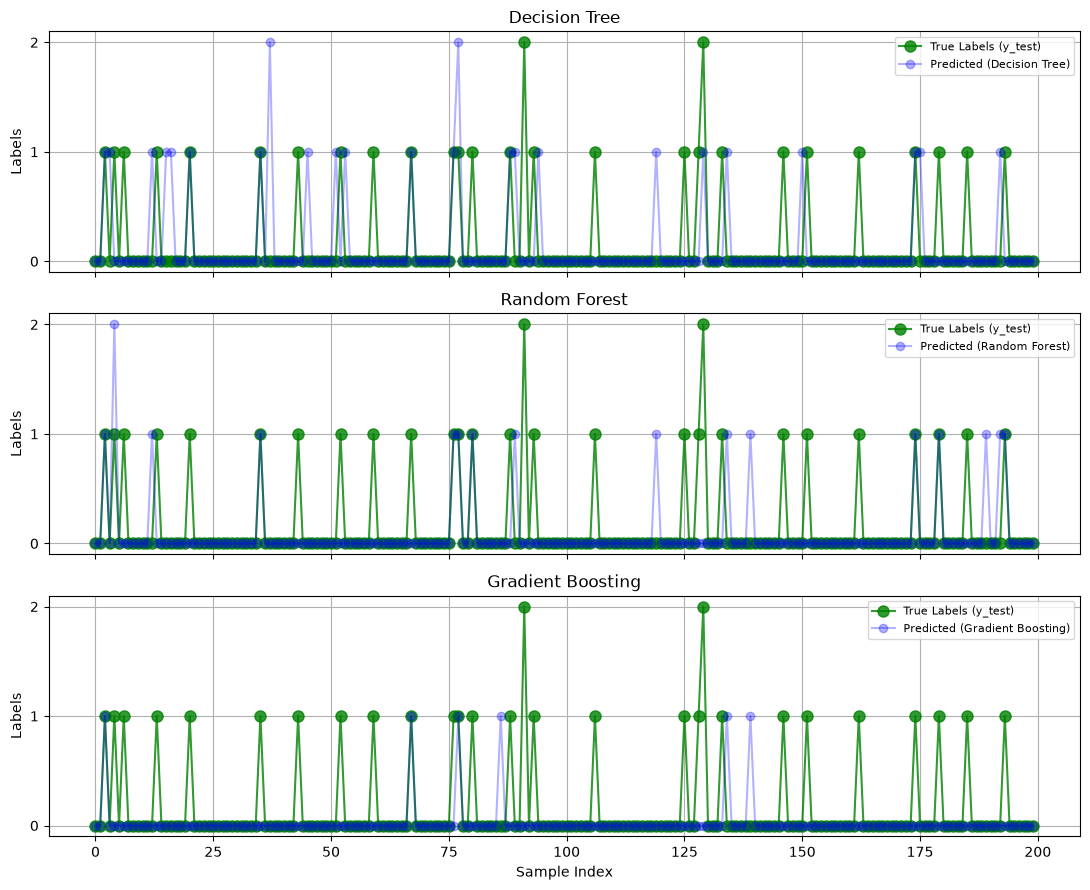

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

for ax, (name, pred) in zip(axes, predictions.items()):
    ax.plot(y_test[:200], "go-", label="True Labels (y_test)", markersize=8, alpha=0.8)
    ax.plot(pred[:200], "bo-", label=f"Predicted ({name})", markersize=6, alpha=0.3)
    ax.set(ylabel="Labels", title=name, yticks=[0, 1, 2])
    ax.grid(True)
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Sample Index")
plt.tight_layout()
plt.savefig("figures/true_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

The green line spends most of its time at 0, and so does the blue one. Where green jumps
to 1 - an applicant who was admitted - blue usually stays down. That is the picture
behind the accuracy scores: the models agree with the majority class and little else.

In [13]:
for name, pred in predictions.items():
    correct = np.sum(y_test == pred)
    incorrect = np.sum(y_test != pred)
    admits_found = np.sum((y_test == 1) & (pred == 1))
    print(f"{name}")
    print(f"   correct {correct}   incorrect {incorrect}   accuracy {correct / len(y_test) * 100:.2f}%")
    print(f"   admitted applicants in the test set: {(y_test == 1).sum()}, of which found: {admits_found}")

Decision Tree
   correct 961   incorrect 278   accuracy 77.56%
   admitted applicants in the test set: 182, of which found: 57
Random Forest
   correct 1014   incorrect 225   accuracy 81.84%
   admitted applicants in the test set: 182, of which found: 39
Gradient Boosting
   correct 1021   incorrect 218   accuracy 82.41%
   admitted applicants in the test set: 182, of which found: 14


## What this says

Copying the reference method exactly reproduces its 98.87% - and with trees, 100% - but
that number is the feature list leaking the answer, not a model working. With the leak
closed, none of the three trees beats the rule "turn everyone down", which scores 0.8402
on this split.

The models are not useless; the task is imbalanced and three-class, and accuracy is the
wrong instrument for it. `A4_TreeBased_Classification.ipynb` takes the same data as a
binary problem and looks at precision, recall and ROC-AUC instead.